Logo file not found, creating a placeholder.


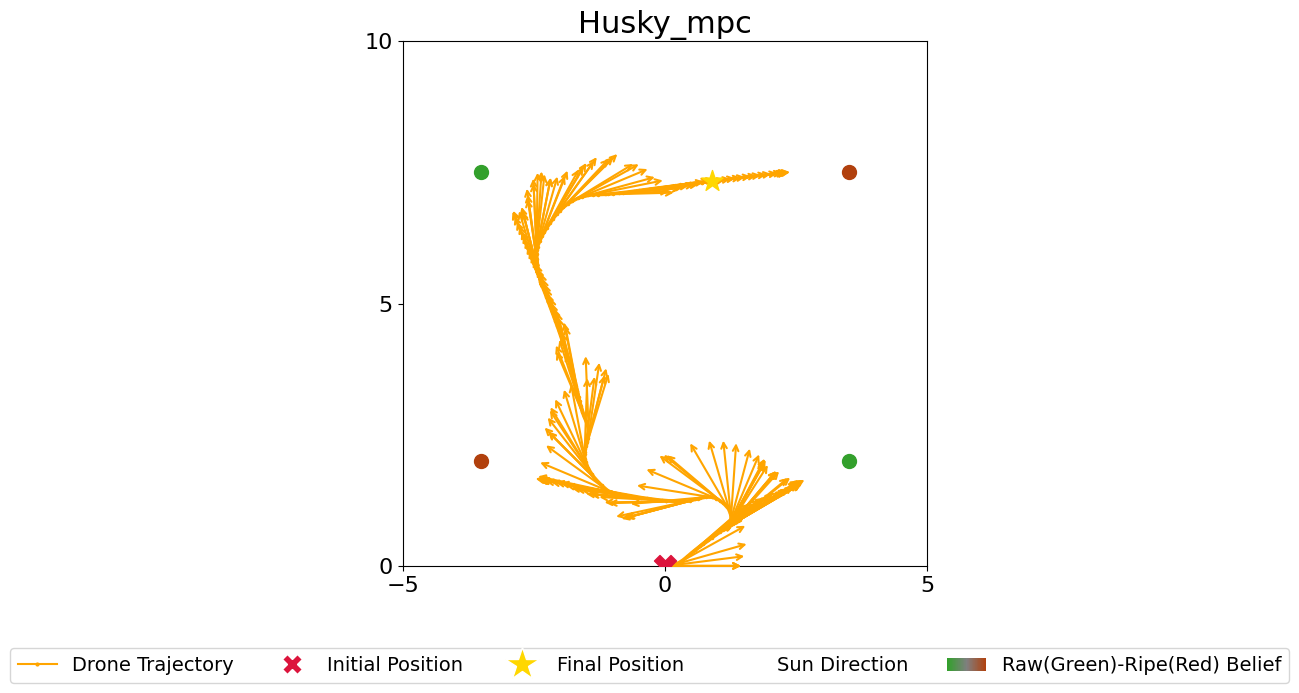

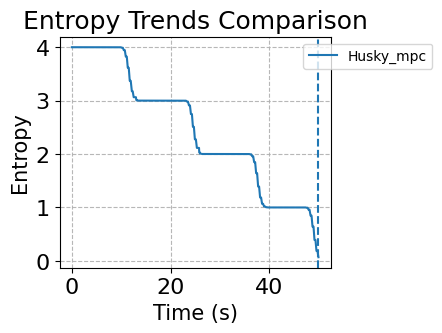

In [4]:
# %% [markdown]
# # Trajectory and Entropy Visualization (Multi-Mode)
# This notebook compares drone trajectories and entropy trends across multiple planning strategies.

# %%
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import seaborn as sns
from PIL import Image
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.ticker import MultipleLocator
# New imports for the custom legend handler
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerBase


import io

# %% [markdown]
# ## Load logo and set color palettes

# %%
try:
    logo_arr = mpimg.imread("/home/pantheon/drea/neural_mpc/ros/src/nmpc_ros/results/sun_orientation.png")
except:
    print("Logo file not found, creating a placeholder.")
    logo_arr = np.zeros((10, 10, 4)) # Create a transparent placeholder if logo is missing

paired_palette = sns.color_palette("Paired")
dark_paired_palette = sns.color_palette("dark")

# %%
# Define the custom handler for the gradient legend
class HandlerGradient(HandlerBase):
    def __init__(self, cmap, num_stripes=64, **kw):
        super().__init__(**kw)
        self.cmap = cmap
        self.num_stripes = num_stripes

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        # Create a strip of colors
        gradient = np.linspace(0, 1, self.num_stripes)
        colors = self.cmap(gradient)
        
        # Create a collection of patches (rectangles) for the gradient bar
        stripes = []
        for i in range(self.num_stripes):
            stripe = mpatches.Rectangle([xdescent + i * width / self.num_stripes, ydescent],
                                     width / self.num_stripes,
                                     height,
                                     fc=colors[i],
                                     transform=trans,
                                     edgecolor='none')
            stripes.append(stripe)
        
        return stripes

# Define the custom handler for an image in the legend
class HandlerImage(HandlerBase):
    def __init__(self, image_arr, zoom=1.0, **kw):
        super().__init__(**kw)
        self.image_arr = image_arr
        self.zoom = zoom

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        # Create an OffsetImage from the image array
        imagebox = OffsetImage(self.image_arr, zoom=self.zoom)
        # Create an AnnotationBbox to place the image at the center of the legend handle's area
        ab = AnnotationBbox(imagebox,
                            (xdescent + 0.5 * width, ydescent + 0.5 * height),
                            frameon=False,
                            xycoords=trans, # Use the transform provided by the legend
                            box_alignment=(0.5, 0.5), # Align the center of the image with the point
                            pad=0)
        return [ab]


# %%
def get_latest_csv(mode, directory, suffix="plot_data.csv"):
    pattern = os.path.join(directory, f"{mode}*{suffix}")
    files = glob.glob(pattern)
    if not files:
        return None
    return max(files, key=os.path.getmtime)

# %%
def load_csv_data(csv_path):
    with open(csv_path, 'r') as f:
        first_line = f.readline().strip()
    parts = first_line.split(',')
    if parts[0] == "tree_positions":
        tree_positions_list = [float(x) for x in parts[1:] if x]
        if tree_positions_list:
            num_trees = len(tree_positions_list) // 2
            tree_positions = np.array(tree_positions_list).reshape(num_trees, 2)
        else:
            tree_positions = np.array([]).reshape(0,2)
    else:
        tree_positions = None

    df = pd.read_csv(csv_path, skiprows=2)
    return (
        df["time"].values,
        df["x"].values,
        df["y"].values,
        df["theta"].values,
        df["entropy"].values,
        df[[col for col in df.columns if col.startswith("lambda_")]].values,
        tree_positions
    )

# %%
def plot_trajectory_subplot(ax, x, y, theta, trees, lambda_history, custom_cmap,
                            tree_label_fontsize, legend_fontsize_param,
                            axis_label_fontsize, tick_label_fontsize,
                            subplot_title_fontsize,
                            mode_label_for_title):
    ax.plot(x, y, marker='o', color='orange', linewidth=2.5, markersize=1.5, label="Drone Trajectory")
    ax.scatter(x[0], y[0], color='crimson', s=250, marker='X', label="Initial Position", zorder=4)
    ax.scatter(x[-1], y[-1], color='gold', s=250, marker='*', label="Final Position", zorder=4)

    if trees is not None and trees.size > 0:
        # Note: The colormap goes from green (low lambda) to red (high lambda)
        for i in range(trees.shape[0]):
            final_lambda = lambda_history[-1, i] if lambda_history.shape[1] > i else 0.5
            tree_color = custom_cmap(final_lambda)
            ax.scatter(trees[i, 0], trees[i, 1], color=tree_color, s=100, marker='o', zorder=3)

    step = max(1, len(x) // 300)
    for idx_arr in range(0, len(x), step):
        x0, y0, t = x[idx_arr], y[idx_arr], theta[idx_arr]
        x1 = x0 + 1.5 * np.cos(t)
        y1 = y0 + 1.5 * np.sin(t)
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="->", color="orange", linewidth=1.5))

    ax.tick_params(axis='both', labelsize=tick_label_fontsize)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-5.0, 5.0)
    ax.set_ylim(0.0, 10.0)
    ax.set_title(mode_label_for_title, fontsize=subplot_title_fontsize)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(5))
# %%
def plot_entropy_subplot(ax, time_history, entropy, label, color, axis_label_fontsize, tick_label_fontsize):
    ax.plot(time_history, entropy, linewidth=1.5, markersize=1.0, label=label, color=color)
    ax.set_xlabel("Time (s)", fontsize=axis_label_fontsize)
    ax.set_ylabel("Entropy", fontsize=axis_label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_label_fontsize)

# %% [markdown]
# ## Multi-mode Comparison

# %%
modes = ["husky_mpc"] #"greedy", "linear","mower_good", "mower_bad"]
#modes = ["mpc", "greedy", "linear"]
baselines_dir = "../to_plot"

axis_label_fontsize = 15
tick_label_fontsize = 16
subplot_title_fontsize = 22
legend_fontsize = 14
suptitle_fontsize = 18
tree_label_fontsize = 10

# The colormap represents the belief: Raw (Green, lambda=0) -> Uncertain (Gray) -> Ripe (Red, lambda=1)
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap", [paired_palette[3], (0.5, 0.5, 0.5), dark_paired_palette[1]]
)
algorithm_labels = {
    "linear": "Linear Path",
    "greedy": "Greedy Approach",
    "mower": "Mower Path",
    "mower_good": "Mower Path - Good View",
    "mower_bad": "Mower Path - Poor View",
    "mpc": "Neural IPP MPC",
}

# %%
# Define grid layout for trajectory plots
nrows = 1
ncols = (len(modes) + nrows - 1) // nrows  # Calculate columns needed, ceiling division

fig_traj, axs_traj = plt.subplots(nrows, ncols, figsize=(6 * 1, 6.5 * nrows), squeeze=False)
axs_flat = axs_traj.flatten() # Flatten the 2D array of axes for easy iteration
fig_entropy, ax_entropy = plt.subplots(figsize=(3.5, 3))

colors = sns.color_palette("tab10", len(modes))
any_trees = False

for i, mode in enumerate(modes):
    label = algorithm_labels.get(mode, mode.capitalize())
    csv_file = get_latest_csv(mode, baselines_dir)
    if not csv_file:
        print(f"No CSV found for {mode}")
        # Turn off the axis for this missing mode
        if i < len(axs_flat):
            axs_flat[i].axis('off')
        continue
    try:
        time_h, x, y, theta, entropy, lambda_h, trees = load_csv_data(csv_file)
        if trees is not None and trees.size > 0:
            any_trees = True
    except Exception as e:
        print(f"Error loading {csv_file}: {e}")
        # Turn off the axis for this problematic mode
        if i < len(axs_flat):
            axs_flat[i].axis('off')
        continue

    ax_t = axs_flat[i] # Use the flattened array to get the current subplot axis
    plot_trajectory_subplot(ax_t, x, y, theta, trees, lambda_h, custom_cmap,
                            tree_label_fontsize, legend_fontsize,
                            axis_label_fontsize, tick_label_fontsize,
                            subplot_title_fontsize, label)
    oim = OffsetImage(logo_arr, zoom=0.075)
    ab = AnnotationBbox(oim, (-0.01, 1.01), xycoords="axes fraction", frameon=False)
    ax_t.add_artist(ab)

    plot_entropy_subplot(ax_entropy, time_h, entropy, label, colors[i],
                         axis_label_fontsize, tick_label_fontsize)
    
    # *** NEW LINE ADDED HERE ***
    # Add a vertical line at the end time of the run
    ax_entropy.axvline(x=time_h[-1], color=colors[i], linestyle='--', linewidth=1.5)


# Hide any unused subplots if the number of modes is not a multiple of ncols
for i in range(len(modes), len(axs_flat)):
    axs_flat[i].axis('off')

# %%
# Finalize Trajectory Plot
legend_handles = [
    Line2D([0], [0], color='orange', lw=1.5, marker='o', markersize=2, label='Drone Trajectory'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='crimson', markersize=15, label='Initial Position'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markersize=25, label='Final Position')
]
legend_labels = ['Drone Trajectory', 'Initial Position', 'Final Position']

# Create dummy handles for custom legend items
image_handle = mpatches.Patch(color='none')
legend_handles.append(image_handle)
legend_labels.append('Sun Direction')

# Build the handler map for custom legend artists
handler_map = {
    image_handle: HandlerImage(logo_arr, zoom=0.04) # Adjust zoom for legend size
}

# Conditionally add the gradient legend for tree belief
if any_trees:
    gradient_handle = mpatches.Patch(color='none')
    legend_handles.append(gradient_handle)
    legend_labels.append('Raw(Green)-Ripe(Red) Belief')
    handler_map[gradient_handle] = HandlerGradient(cmap=custom_cmap)

#fig_traj.suptitle("Algorithm Trajectories Comparison", fontsize=suptitle_fontsize)
# Adjust layout to make room for suptitle and legend
fig_traj.tight_layout(rect=[0, 0.05, 1, 0.95])
fig_traj.legend(
    handles=legend_handles, 
    labels=legend_labels,
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.1), 
    ncol=5, 
    fontsize=legend_fontsize,
    # Map the dummy handles to our custom artist handlers
    handler_map=handler_map
)

output_path_traj = os.path.join(baselines_dir, f"thesis_mpc_trajectory_grid.png")
fig_traj.savefig(output_path_traj, format='png', bbox_inches='tight',  dpi=350)

# Finalize Entropy Plot
ax_entropy.set_title("Entropy Trends Comparison", fontsize=suptitle_fontsize)
ax_entropy.legend(loc='upper right',  bbox_to_anchor=(1.4, 1.0))
ax_entropy.grid(True, linestyle='--', alpha=0.9)
output_path_entropy = os.path.join(baselines_dir, f"entropy_comparison.png")
fig_entropy.savefig(output_path_entropy, format='png', bbox_inches='tight', dpi=350)

# Show all generated plots
plt.show()

In [ ]:
#!/usr/bin/env python
import os
import re
import rospy
import torch
import math
import numpy as np
import tf
from nav_msgs.msg import Odometry
from std_msgs.msg import Float32MultiArray, MultiArrayDimension
from gazebo_msgs.srv import SpawnModel
from geometry_msgs.msg import Pose, Point, Quaternion
import threading

# --- Stessa definizione usata nell'NMPC ---
class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self, input_dim, hidden_size=64, hidden_layers=3):
        super().__init__()
        in_features = input_dim if input_dim != 3 else input_dim + 1
        self.input_layer = torch.nn.Linear(in_features, hidden_size)
        self.hidden_layer = torch.nn.ModuleList(
            [torch.nn.Linear(hidden_size, hidden_size) for _ in range(hidden_layers)]
        )
        self.out_layer = torch.nn.Linear(hidden_size, 1)

    def forward(self, x):
        if x.shape[-1] == 3:
            sin_cos = torch.cat([torch.sin(x[..., -1:]), torch.cos(x[..., -1:])], dim=-1)
            x = torch.cat([x[..., :-1], sin_cos], dim=-1)
        x = self.input_layer(x)
        for layer in self.hidden_layer:
            x = torch.tanh(layer(x))
        x = self.out_layer(x)
        return x

class CarScoresMock:
    def __init__(self):
        rospy.init_node('car_scores_mock_node', anonymous=True)
        
        # 1. Configurazione Macchine: "in fila" che puntano verso le X positive
        self.cars_pos = np.array([
            [4.0, 2.0]
        ], dtype=np.float32)
        
        self.gt_ids = [1, 0] # 1: Ripe (Verde), 0: Raw (Rossa)
        self.num_cars = len(self.cars_pos)
        
        self.robot_pos = None
        self.robot_yaw = 0.0
        self.dt = 0.2 # 5 Hz
        
        # 2. Inizializzazione Reti Neurali
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.models = {}
        rospy.loginfo("[Mock] Caricamento reti neurali...")
        for label in ['car', 'car']:
            model = MultiLayerPerceptron(input_dim=3, hidden_size=64, hidden_layers=3)
            model_path = self.get_latest_best_model(label)
            model.load_state_dict(torch.load(model_path, map_location=self.device))
            model.to(self.device)
            model.eval()
            self.models[label] = model
        
        # 3. Publisher e Subscriber ROS
        self.sub_odom = rospy.Subscriber('/odometry/filtered', Odometry, self.odom_callback)
        self.pub_scores = rospy.Publisher('tree_scores', Float32MultiArray, queue_size=10)
        
        rospy.loginfo("[+] Nodo Mock Auto-Percettivo avviato. In attesa di odometria...")

        threading.Thread(target=self.spawn_cars_in_gazebo).start()

    def get_latest_best_model(self, cls=''):
        script_dir = os.path.dirname(os.path.abspath(__file__))
        model_dir = os.path.join(script_dir, "models", cls)
        # Fallback nel caso il mock sia lanciato da una root diversa
        if not os.path.exists(model_dir):
            model_dir = os.path.join(script_dir, "..", "models", cls) 
            
        model_files = [f for f in os.listdir(model_dir) if re.match(r"best_model_epoch_(\d+)\.pth", f)]
        if not model_files:
            raise FileNotFoundError(f"Nessun modello trovato in {model_dir}")
        latest_model = max(model_files, key=lambda x: int(re.match(r"best_model_epoch_(\d+)\.pth", x).group(1)))
        return os.path.join(model_dir, latest_model)

    def odom_callback(self, msg):
        self.robot_pos = np.array([
            msg.pose.pose.position.x,
            msg.pose.pose.position.y
        ])
        # Estrazione Yaw dal quaternione
        ori = msg.pose.pose.orientation
        quat = [ori.x, ori.y, ori.z, ori.w]
        (_, _, self.robot_yaw) = tf.transformations.euler_from_quaternion(quat)

    def run(self):
        rate = rospy.Rate(int(1/self.dt))
        
        while not rospy.is_shutdown():
            scores = np.ones((self.num_cars, 2), dtype=np.float32) * 0.5
            
            if self.robot_pos is not None:
                with torch.no_grad():
                    for i in range(self.num_cars):
                        # Calcolo input rete: Diff X, Diff Y, Angolo Normale Sinistra
                        diff_x = self.robot_pos[0] - self.cars_pos[i, 0]
                        diff_y = self.robot_pos[1] - self.cars_pos[i, 1]
                        left_normal_angle = self.robot_yaw + (math.pi / 2.0)
                        
                        nn_input = torch.tensor([diff_x, diff_y, left_normal_angle], dtype=torch.float32).unsqueeze(0).to(self.device)
                        
                        if self.gt_ids[i] == 1: # Ground Truth è Ripe
                            logit = self.models['car'](nn_input)
                            p_correct = torch.sigmoid(logit).item()
                            scores[i] = [1.0 - p_correct, p_correct]
                        else:                   # Ground Truth è Raw
                            logit = self.models['car'](nn_input)
                            p_correct = torch.sigmoid(logit).item()
                            scores[i] = [p_correct, 1.0 - p_correct]
            else:
                rospy.logwarn_throttle(2.0, "[Mock] Nessun dato odometrico. Invio score neutri [0.5, 0.5]")

            # Standardizzazione output array per NMPC
            msg = Float32MultiArray()
            msg.layout.dim.append(MultiArrayDimension(label="rows", size=self.num_cars, stride=self.num_cars * 2))
            msg.layout.dim.append(MultiArrayDimension(label="cols", size=2, stride=2))
            
            # per non dare informazioni tutto a 0.5
            scores = np.ones((self.num_cars, 2), dtype=np.float32) * 0.5

            msg.data = scores.flatten().tolist()
            
            self.pub_scores.publish(msg)
            rate.sleep()

    def spawn_cars_in_gazebo(self):
        rospy.loginfo("[Mock] In attesa del servizio di spawn di Gazebo...")
        service_name = '/gazebo/spawn_sdf_model'
        try:
            rospy.wait_for_service(service_name, timeout=10.0)
            spawn_model_client = rospy.ServiceProxy(service_name, SpawnModel)
            
            for i, pos in enumerate(self.cars_pos):
                model_name = f"mock_car_{i}"
                
                # Se il punto di repere è a 15cm (0.15m) dalla punta frontale,
                # E la macchina è lunga 4.0m, il centro della macchina si trova a -1.85m lungo l'asse X.
                # Dimensioni: Lunghezza 4.0, Larghezza 1.8, Altezza 1.4
                
                color = "0 1 0 1" if self.gt_ids[i] == 1 else "1 0 0 1" # Verde Ripe, Rosso Raw
                
                sdf_string = f"""
                <sdf version='1.6'>
                  <model name='{model_name}'>
                    <static>true</static>
                    <link name='chassis'>
                      <collision name='body_collision'>
                        <pose>-1.85 0 0.7 0 0 0</pose>
                        <geometry><box><size>4.0 1.8 1.4</size></box></geometry>
                      </collision>
                      <visual name='body_visual'>
                        <pose>-1.85 0 0.7 0 0 0</pose>
                        <geometry><box><size>4.0 1.8 1.4</size></box></geometry>
                        <material>
                          <ambient>{color}</ambient>
                          <diffuse>{color}</diffuse>
                        </material>
                      </visual>
                      
                      <visual name='front_grill'>
                        <pose>0.10 0 0.5 0 0 0</pose> <geometry><box><size>0.1 1.6 0.3</size></box></geometry>
                        <material>
                          <ambient>1 1 0 1</ambient> <diffuse>1 1 0 1</diffuse>
                        </material>
                      </visual>
                    </link>
                  </model>
                </sdf>
                """
                
                # Applichiamo la posa fornita alla radice del modello. 
                # L'offset del baricentro è gestito all'interno dell'SDF
                pose = Pose()
                pose.position = Point(x=pos[0], y=pos[1], z=0.0)
                
                spawn_model_client(
                    model_name=model_name,
                    model_xml=sdf_string,
                    robot_namespace="",
                    initial_pose=pose,
                    reference_frame="world"
                )
            rospy.loginfo("[Mock] Le automobili simulate sono state posizionate in Gazebo.")
            
        except (rospy.ServiceException, rospy.ROSException) as e:
            rospy.logerr(f"[Mock] Impossibile spawnare le auto in Gazebo: {e}")

if __name__ == '__main__':
    try:
        mock = CarScoresMock()
        mock.run()
    except rospy.ROSInterruptException:
        pass